# HATR cross-framework — Performance computazionale

Confronto del costo computazionale di HATR in River (Python) e CapyMOA (JVM via JNI) su 4 dataset: tempo di training, inferenza, throughput e crescita della dimensione modello.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jpype
import jpype.config
jpype.config.destroy_jvm = False

HATR_JAR = os.path.normpath(os.path.join(os.getcwd(), '..', 'implementation',
    'hatr-moa', 'target',
    'hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar'))
assert os.path.exists(HATR_JAR), f"JAR non trovato: {HATR_JAR}\ncompilare: cd implementation/hatr-moa && mvn -o package -DskipTests"

if jpype.isJVMStarted():
    print('JVM già avviata — Kernel → Restart & Run All')
else:
    SIZEOF_JAR = os.path.expanduser(
        "~/.m2/repository/com/github/fracpete/sizeofag/1.1.0/sizeofag-1.1.0.jar")
    if os.path.exists(SIZEOF_JAR):
        os.environ["CAPYMOA_JVM_ARGS"] = (
            f"-Xmx8g -Xss10M -javaagent:{SIZEOF_JAR} "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.lang.reflect=ALL-UNNAMED "
            "-XX:ErrorFile=/dev/null"
        )
    else:
        os.environ["CAPYMOA_JVM_ARGS"] = "-Xmx8g -Xss10M -XX:ErrorFile=/dev/null"
    jpype.addClassPath(HATR_JAR)

from capymoa.datasets import Bike, Fried
from capymoa.stream.generator import HyperPlaneRegression
import psutil
from pympler import asizeof

import utils   # importato dopo JVM: gestisce sys.path, capymoa, river, hatr_capymoa

print("Setup OK — JVM avviata, HATR caricato, River e CapyMOA importati")

Setup OK — JVM avviata, HATR caricato, River e CapyMOA importati


## Dataset

In [2]:
MAX_INSTANCES = 17000
SYN_N, SYN_DRIFT = 10000, 5000

datasets = {}
datasets["Synthetic"] = utils.make_synthetic(n=SYN_N, drift_at=SYN_DRIFT)
datasets["Bike"]      = utils.materialize_stream(Bike(), MAX_INSTANCES)
datasets["Fried"]     = utils.materialize_stream(Fried(), MAX_INSTANCES)
datasets["Hyper"]     = utils.materialize_stream(
    HyperPlaneRegression(instance_random_seed=1, number_of_attributes=10,
                         number_of_drifting_attributes=2, magnitude_of_change=0.001,
                         noise_percentage=5),
    MAX_INSTANCES)

for name, (X, y, schema) in datasets.items():
    print(f"{name:<10} n={len(X):>6}  feat={X.shape[1]:>2}  y∈[{y.min():.2f}, {y.max():.2f}]")

Synthetic  n= 10000  feat= 5  y∈[-14.45, 15.29]
Bike       n= 17000  feat=12  y∈[1.00, 977.00]
Fried      n= 17000  feat=10  y∈[-1.23, 30.05]
Hyper      n= 17000  feat=10  y∈[93.98, 677.42]


## Parametri

In [3]:
BASE = dict(grace_period=200, delta=1e-7, tau=0.05, model_selector_decay=0.95,
            drift_window_threshold=500, switch_significance=0.05,
            min_samples_split=5, adwin_delta=0.0001, learning_ratio=0.01, seed=0)

CONFIGS = {
    "deterministic (mean, no-bootstrap)": dict(leaf_prediction="mean",     bootstrap_sampling=False),
    "default (adaptive, bootstrap)":      dict(leaf_prediction="adaptive", bootstrap_sampling=True),
}

SCALE = True

## Esecuzione

In [4]:
SAMPLE_EVERY = 500
PERF_CONFIG  = "default (adaptive, bootstrap)"
cfg = CONFIGS[PERF_CONFIG]

rows = []
for ds_name, (X, y, schema) in datasets.items():
    n = len(X)
    rt_p, rt_t, r_model   = utils.timed_prequential_river(X, y, cfg, BASE)
    ct_p, ct_t, c_learner = utils.timed_prequential_capy(X, y, schema, cfg, BASE)
    r_mb = utils.river_model_mb(r_model)
    c_mb = utils.capy_model_mb(c_learner)
    rows.append(dict(dataset=ds_name, framework="River", n=n,
                     train_s=rt_t, predict_s=rt_p, total_s=rt_t + rt_p,
                     inst_per_s=n / (rt_t + rt_p), model_MB=r_mb))
    rows.append(dict(dataset=ds_name, framework="CapyMOA", n=n,
                     train_s=ct_t, predict_s=ct_p, total_s=ct_t + ct_p,
                     inst_per_s=n / (ct_t + ct_p), model_MB=c_mb))
    print(f"  {ds_name:<10} River {rt_t+rt_p:6.2f}s {r_mb:.3f} MB  |  CapyMOA {ct_t+ct_p:6.2f}s {c_mb:.4f} MB")

perf = pd.DataFrame(rows)
speedup = (perf[perf.framework == "CapyMOA"].set_index("dataset")["inst_per_s"] /
           perf[perf.framework == "River"].set_index("dataset")["inst_per_s"])
perf["speedup_vs_river"] = perf["dataset"].map(speedup)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
perf

  Synthetic  River   0.47s 1.462 MB  |  CapyMOA   0.40s 0.2188 MB
  Bike       River   1.02s 0.182 MB  |  CapyMOA   0.54s 0.1314 MB
  Fried      River   1.34s 2.654 MB  |  CapyMOA   0.55s 0.2833 MB
  Hyper      River   1.47s 0.704 MB  |  CapyMOA   0.36s 0.4439 MB


,dataset,framework,n,train_s,predict_s,total_s,inst_per_s,model_MB,speedup_vs_river
0,Synthetic,River,10000,0.4373,0.0323,0.4696,21294.2387,1.4617,1.1763
1,Synthetic,CapyMOA,10000,0.2978,0.1014,0.3992,25048.9166,0.2188,1.1763
2,Bike,River,17000,0.9717,0.0525,1.0241,16599.2597,0.1822,1.9065
3,Bike,CapyMOA,17000,0.4768,0.0603,0.5372,31646.4784,0.1314,1.9065
4,Fried,River,17000,1.2766,0.0612,1.3378,12707.3656,2.6539,2.4368
5,Fried,CapyMOA,17000,0.4913,0.0577,0.5490,30964.7807,0.2833,2.4368
6,Hyper,River,17000,1.4062,0.0596,1.4658,11597.7422,0.7035,4.0737
7,Hyper,CapyMOA,17000,0.3018,0.0580,0.3598,47245.6990,0.4439,4.0737


## Grafici

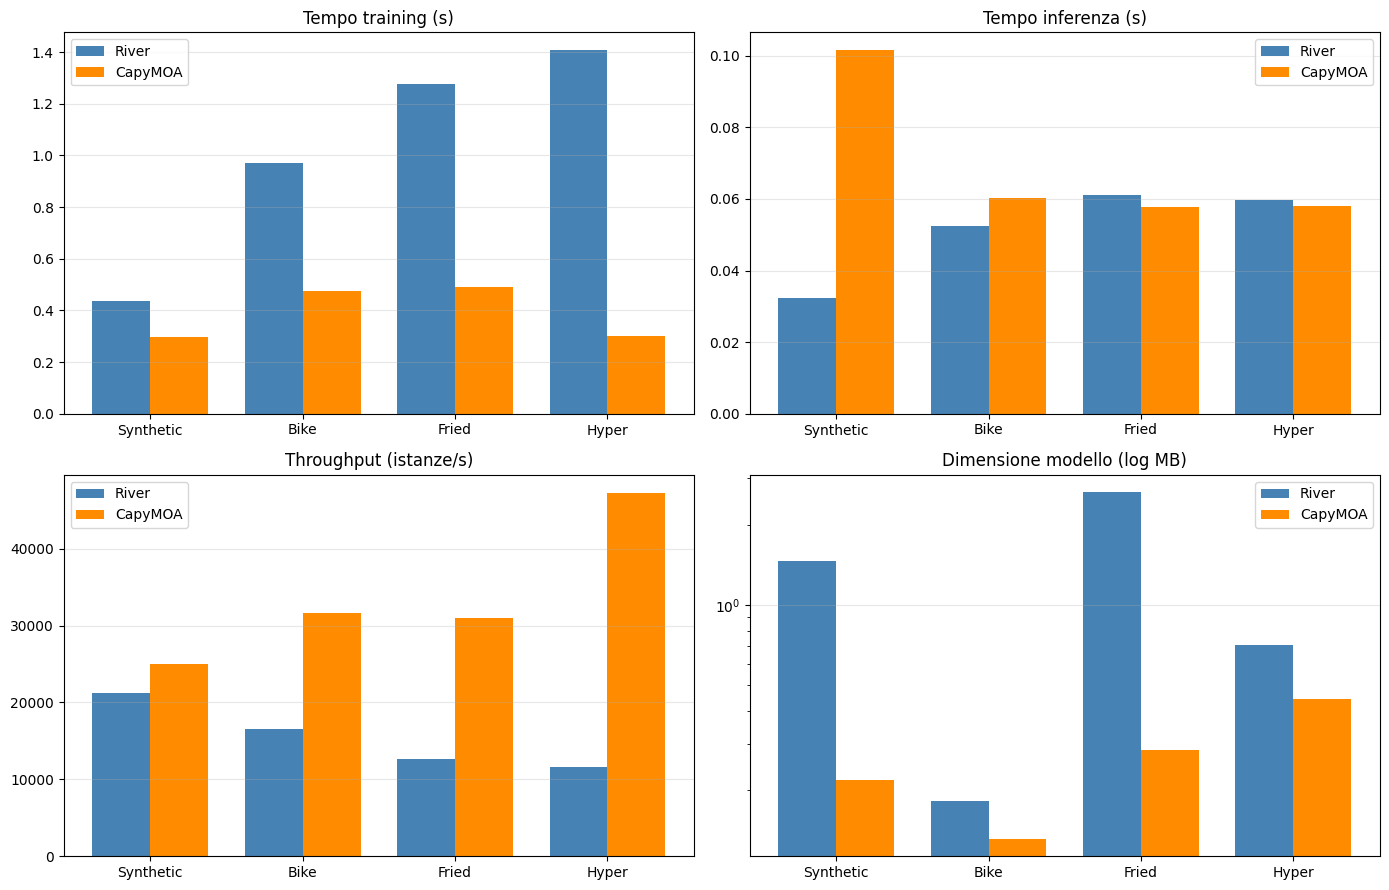

  dataset framework  train_s  predict_s  inst_per_s  model_MB  speedup_vs_river
Synthetic     River   0.4373     0.0323  21294.2387    1.4617            1.1763
Synthetic   CapyMOA   0.2978     0.1014  25048.9166    0.2188            1.1763
     Bike     River   0.9717     0.0525  16599.2597    0.1822            1.9065
     Bike   CapyMOA   0.4768     0.0603  31646.4784    0.1314            1.9065
    Fried     River   1.2766     0.0612  12707.3656    2.6539            2.4368
    Fried   CapyMOA   0.4913     0.0577  30964.7807    0.2833            2.4368
    Hyper     River   1.4062     0.0596  11597.7422    0.7035            4.0737
    Hyper   CapyMOA   0.3018     0.0580  47245.6990    0.4439            4.0737


In [5]:
ds_order = list(datasets.keys())
def vals(metric, fw):
    return [perf[(perf.dataset == d) & (perf.framework == fw)][metric].values[0] for d in ds_order]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
panels = [
    ("train_s",    "Tempo training (s)",         False),
    ("predict_s",  "Tempo inferenza (s)",         False),
    ("inst_per_s", "Throughput (istanze/s)",      False),
    ("model_MB",   "Dimensione modello (log MB)", True),
]
for ax, (metric, title, log_scale) in zip(axes.ravel(), panels):
    rv, cm = vals(metric, "River"), vals(metric, "CapyMOA")
    xpos = np.arange(len(ds_order)); wbar = 0.38
    ax.bar(xpos - wbar/2, rv, wbar, label="River",   color="steelblue")
    ax.bar(xpos + wbar/2, cm, wbar, label="CapyMOA", color="darkorange")
    if log_scale:
        ax.set_yscale("log")
    ax.set_xticks(xpos); ax.set_xticklabels(ds_order); ax.set_title(title)
    ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print(perf[["dataset", "framework", "train_s", "predict_s", "inst_per_s",
            "model_MB", "speedup_vs_river"]].to_string(index=False))

## Crescita dimensione modello

Synthetic: River 0.996 MB | CapyMOA 0.1578 MB
Bike: River 0.251 MB | CapyMOA 0.0437 MB
Fried: River 4.033 MB | CapyMOA 0.6017 MB
Hyper: River 0.779 MB | CapyMOA 0.1145 MB


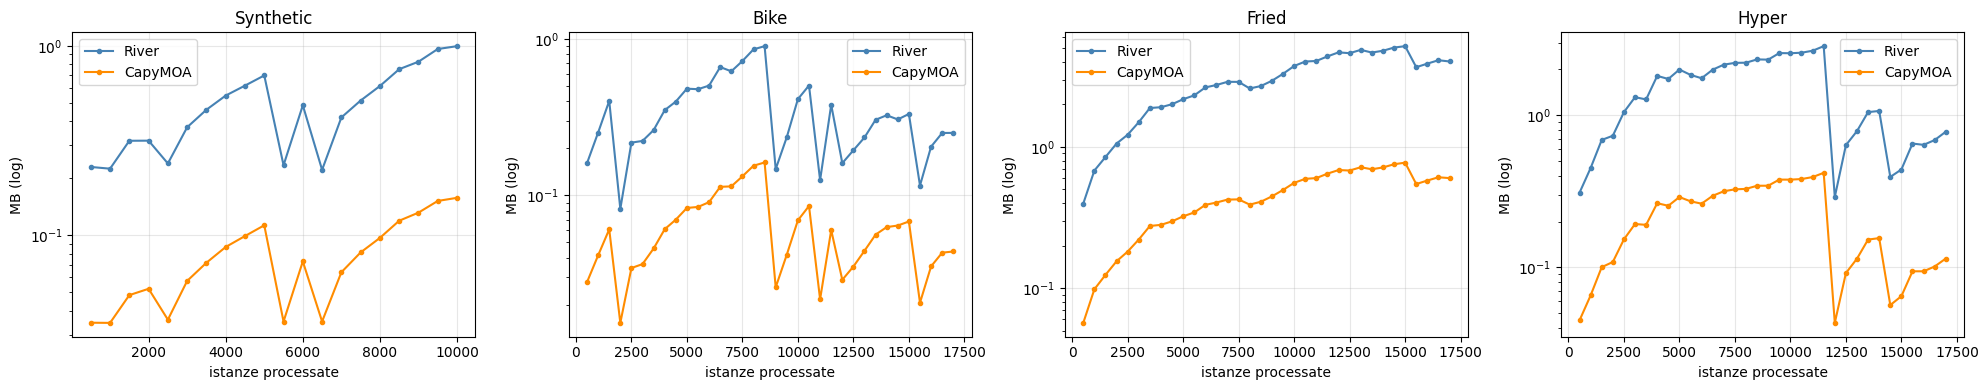

In [6]:
cfg = CONFIGS["deterministic (mean, no-bootstrap)"]
traces = {}
for ds_name, (X, y, schema) in datasets.items():
    tr_r = utils.traced_prequential_river(X, y, cfg, BASE, scale=SCALE, sample_every=SAMPLE_EVERY)
    tr_c = utils.traced_prequential_capy(X, y, schema, cfg, BASE, scale=SCALE, sample_every=SAMPLE_EVERY)
    traces[ds_name] = {"River": tr_r, "CapyMOA": tr_c}
    print(f"{ds_name}: River {tr_r[-1]['model_MB']:.3f} MB | CapyMOA {tr_c[-1]['model_MB']:.4f} MB")

colors  = {"River": "steelblue", "CapyMOA": "darkorange"}
ds_list = list(datasets.keys())

fig, axes = plt.subplots(1, len(ds_list), figsize=(5 * len(ds_list), 4))
for ax, ds_name in zip(axes, ds_list):
    for fw in ("River", "CapyMOA"):
        t  = traces[ds_name][fw]
        ns = [p["n"]        for p in t]
        vs = [p["model_MB"] for p in t]
        ax.plot(ns, vs, label=fw, color=colors[fw], marker="o", markersize=3)
    ax.set_yscale("log")
    ax.set_title(ds_name)
    ax.set_xlabel("istanze processate")
    ax.set_ylabel("MB (log)")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()